In [5]:
%%capture
!python -m pip install matplotlib numpy scikit-learn

# Vorbereitung des Dataset

In [1]:
from sklearn.datasets import load_digits
dataset = load_digits()
x = dataset.data
y = dataset.target
print(f"x-shape: {x.shape}")

x-shape: (1797, 64)


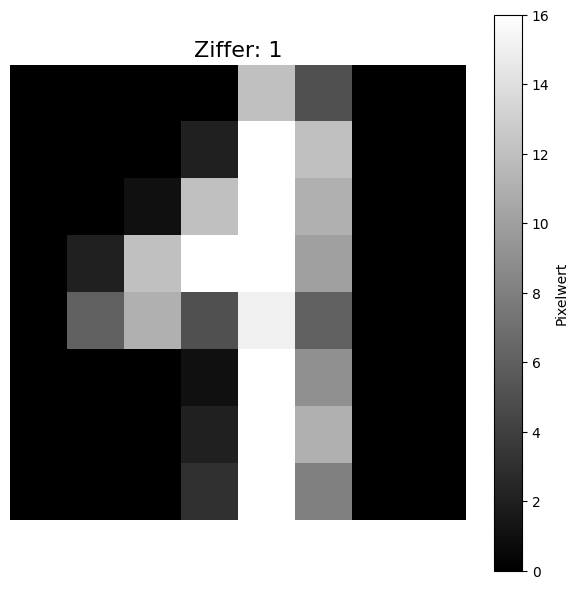

In [2]:
import matplotlib.pyplot as plt

def visualize_digit(index=0, cmap='gray'):
    """
    Visualisiert einen einzelnen Datenpunkt aus dem sklearn digits Dataset.
    
    Parameter:
    ----------
    index : int, optional (default=0)
        Index des zu visualisierenden Datenpunkts (0-1796)
    cmap : str, optional (default='gray')
        Colormap für die Visualisierung
    
    Returns:
    --------
    None
        Zeigt das Bild an
    """
    # Lade das digits Dataset
    digits = load_digits()
    
    # Prüfe, ob der Index gültig ist
    if index < 0 or index >= len(digits.images):
        raise ValueError(f"Index muss zwischen 0 und {len(digits.images)-1} liegen")
    
    # Hole das Bild und das zugehörige Label
    image = digits.images[index]        #Wert aus x-Dataset
    label = digits.target[index]        #Wert aus y-Dataset
    
    # Erstelle die Visualisierung
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap, interpolation='nearest')
    plt.title(f'Ziffer: {label}', fontsize=16)
    plt.axis('off')
    plt.colorbar(label='Pixelwert')
    plt.tight_layout()
    plt.show()

# Beispielaufruf
visualize_digit(42)


In [3]:
print(x.shape)

(1797, 64)


## Aufgabe 1
Bestimmen Sie die Anzahl an Dimensionen, um 90% der Varianz(Informationen) zu behalten

In [ ]:
from sklearn.decomposition import PCA # Importieren der Module
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaler.fit(x)
x_scaled=scaler.transform(x)
pca = PCA(n_components=0.9) # Erstellt ein PCA welcher 90% Varianz behält
pca.fit(x) # Trainiert und Transformiert die Daten
x_pca = pca.transform(x)
print(f"Explained Variance Ratio:\n{pca.explained_variance_ratio_}")
print(f"Sum of Exmplained Variance Ratio:\n{sum(pca.explained_variance_ratio_)}")

Explained Variance Ratio:
[0.14890594 0.13618771 0.11794594 0.08409979 0.05782415 0.0491691
 0.04315987 0.03661373 0.03353248 0.03078806 0.02372341 0.02272697
 0.01821863 0.01773855 0.01467101 0.01409716 0.01318589 0.01248138
 0.01017718 0.00905617 0.00889538]
Sum of Exmplained Variance Ratio:
0.9031985012037212


## Aufgabe 2
Transformieren Sie anschließend die Daten und Spliten Sie das Ergebnis in Trainingsdaten und Testdaten auf. Als Testsizegröße verwenden wir wieder 30%.

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.3)

## Aufgabe 3
Wenden Sie den KNN-Classifier auf den transformierten Daten an.  
Bestimmen Sie das beste Modell!

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

parameters={
    'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    'weights':['uniform','distance']
}
clf = KNeighborsClassifier()
grid_cv = GridSearchCV(clf, parameters, cv=3, n_jobs=-1)
grid_cv.fit(x_train, y_train)
print(grid_cv.best_score_,grid_cv.best_params_)

0.9840891010342084 {'n_neighbors': 2, 'weights': 'distance'}


## Aufgabe 4

Wenden Sie den KNN-Classifier auf den Standardisierten (aber nicht PCA transofrmierten) Daten an.  
Teste Sie auch hier wieder, welche Anzahl an Nachbarn optimal ist.  
Was für Performance-Unterschiede sind zu beobachten? Wählen Sie eine geeignete Metrik aus. 

In [9]:
x_train2,x_test2, y_train2,y_test2=train_test_split=train_test_split(x_scaled,y,test_size=0.3)
clf=KNeighborsClassifier()
parameters={'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],'weights':['uniform','distance']}

grid_cv=GridSearchCV(clf,parameters, cv=5, n_jobs=-1)
grid_cv.fit(x_train,y_train)
print(grid_cv.best_score_,grid_cv.best_params_)

0.9864731549990514 {'n_neighbors': 3, 'weights': 'uniform'}
